In [1]:
import pandas as pd

In [29]:
path='/ptmp/arego/LargeTracks/0.h5'
hits=pd.read_hdf(path,key='hits')

In [30]:
hits

,time,string_id,module_id,pmt_id,record_id,type
0,551.546580,0,18,1,2,2
0,551.571651,0,18,9,2,2
0,551.433588,0,18,11,2,2
0,550.951839,0,18,13,2,2
1,552.845110,0,18,13,2,2
...,...,...,...,...,...,...
0,975.731255,13,5,12,30,2
0,975.499873,13,5,14,30,2
0,1124.933144,13,6,0,30,2
0,1125.022870,13,6,2,30,2


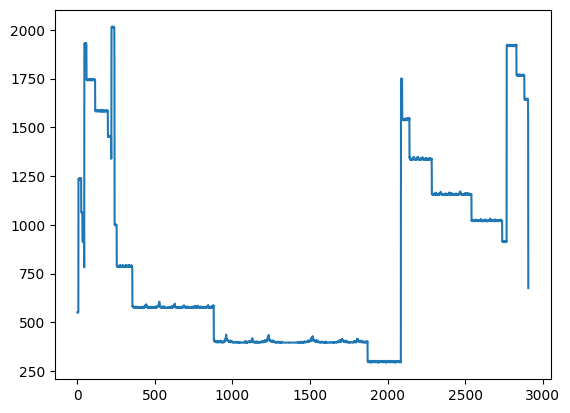

In [38]:
plt.plot(np.arange(hits[hits['record_id']==2].time.shape[0]),hits[hits['record_id']==2].time)

In [7]:
hits.columns

Index(['time', 'string_id', 'module_id', 'pmt_id', 'record_id', 'type'], dtype='object')

In [39]:
from importlib import reload
import DeadTime 
reload(DeadTime)
from DeadTime import process_single_file
import pandas as pd

In [40]:
input_file_path='/ptmp/arego/LargeTracks/0.h5'
output_dir = '/u/arego/project/HiWi/Deadtime/'
deadtime_ns = 1
chunk_size = 10_000_000
debug = True

process_single_file((input_file_path, output_dir, deadtime_ns, chunk_size, debug))


DEBUG: Starting processing of 0.h5
Input file: /ptmp/arego/LargeTracks/0.h5
Output file: /u/arego/project/HiWi/Deadtime/0.h5
Dead time: 1 ns
Chunk size: 10,000,000

DEBUG: Opening file to read keys...
DEBUG: Found keys in file: ['/detector', '/hits', '/records', '/sources']
DEBUG: Getting total row count...
DEBUG: Total rows in 'hits': 176,563

DEBUG: Starting chunked reading...

DEBUG: Processing chunk 1
  - Chunk shape: (176563, 6)
  - Columns: ['time', 'string_id', 'module_id', 'pmt_id', 'record_id', 'type']
  - Unique record_ids in chunk: 20
  - Applying dead time filter...
  - Number of unique PMTs: 2406
  - Number of unique record_ids: 20
  - Filtered: 176563 → 19709 rows (88.8% reduction)

DEBUG: Finished chunked processing
  - Total chunks processed: 1
  - Total filtered chunks: 1

DEBUG: Combining all filtered chunks...
DEBUG: Final combined shape: (19709, 6)
DEBUG: Overall reduction: 176,563 → 19,709 (88.8%)

DEBUG: Writing output file...
DEBUG: Copying non-hits keys: ['/det

('0.h5', True, 'Filtered: 176563 → 19709 hits (88.8% reduction)')

In [12]:
path='/u/arego/project/HiWi/Deadtime/0.h5'
df=pd.read_hdf(path,key='hits')

In [13]:
df

,time,string_id,module_id,pmt_id,record_id,type
0,551.546580,0,18,1,2,2
1,551.571651,0,18,9,2,2
2,551.433588,0,18,11,2,2
3,550.951839,0,18,13,2,2
4,552.845110,0,18,13,2,2
...,...,...,...,...,...,...
19704,975.731255,13,5,12,30,2
19705,975.499873,13,5,14,30,2
19706,1124.933144,13,6,0,30,2
19707,1125.022870,13,6,2,30,2


In [20]:
import matplotlib.pyplot as plt
import numpy as np

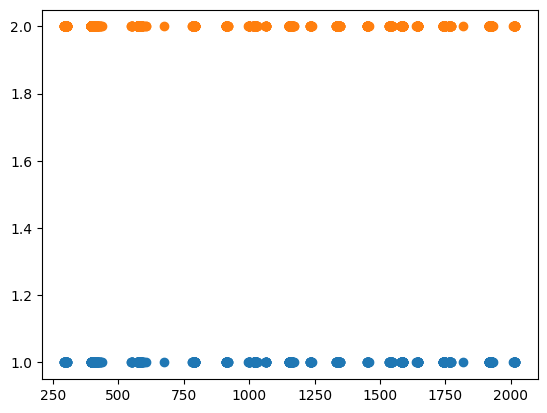

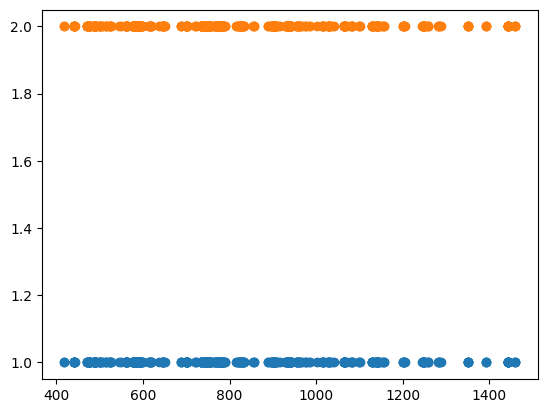

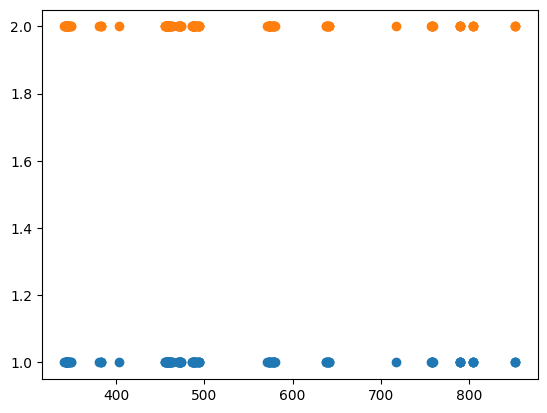

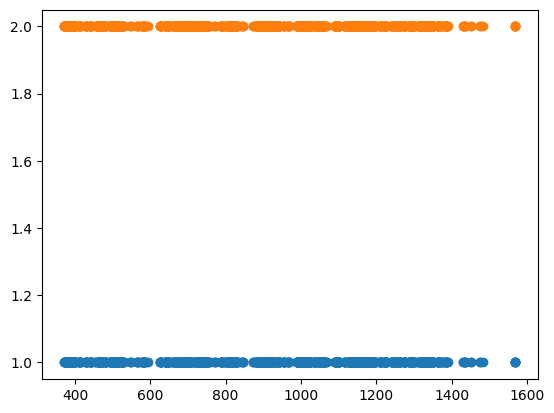

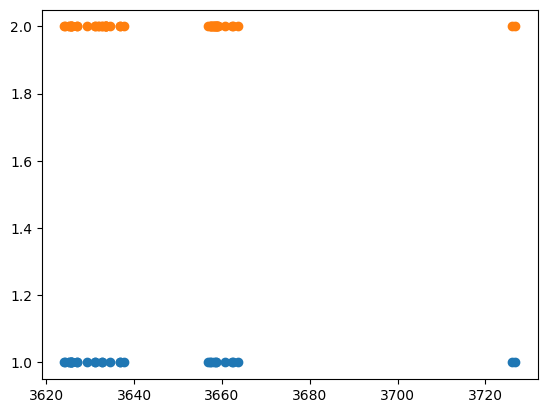

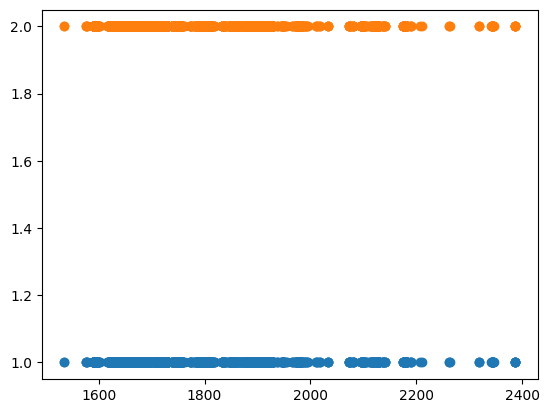

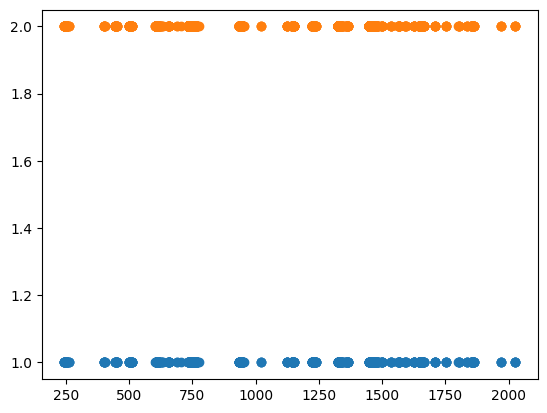

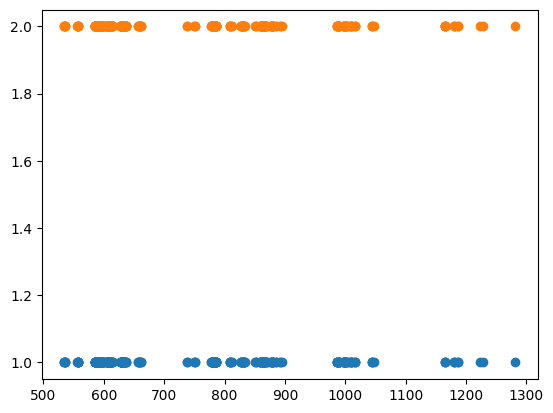

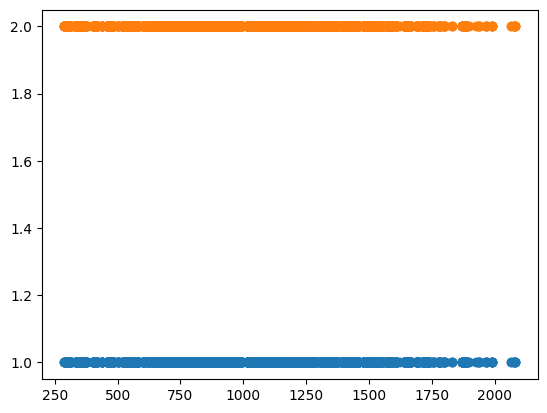

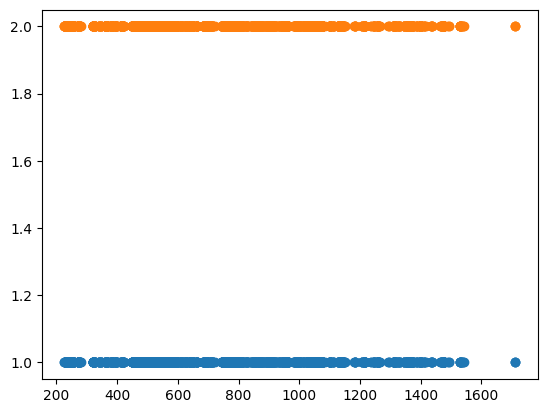

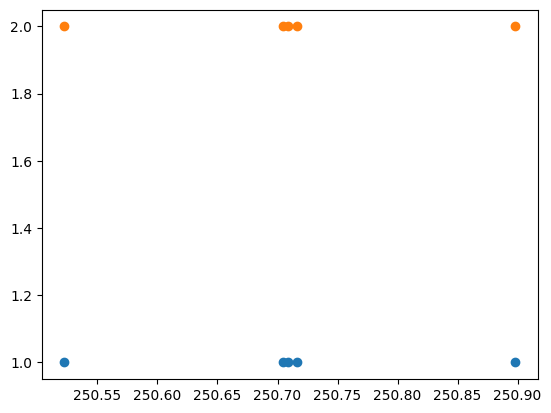

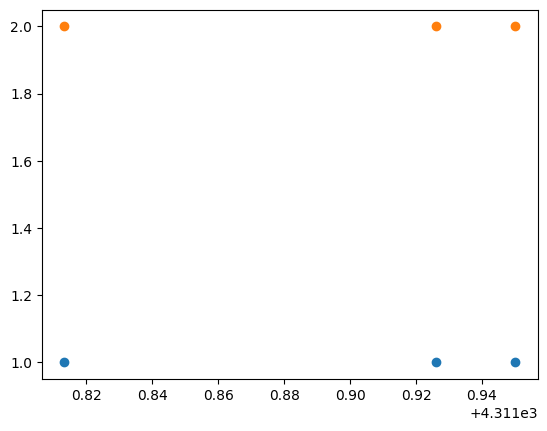

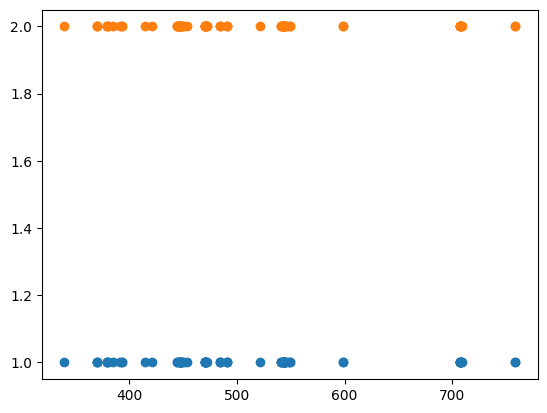

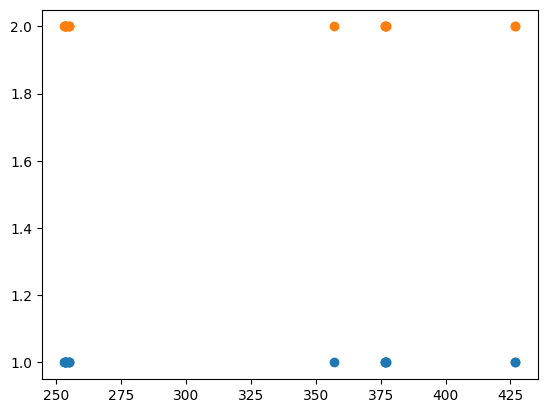

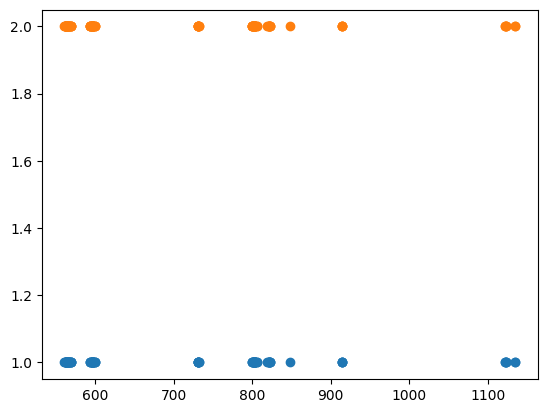

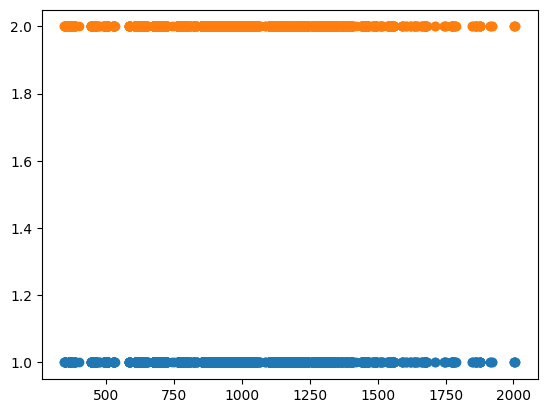

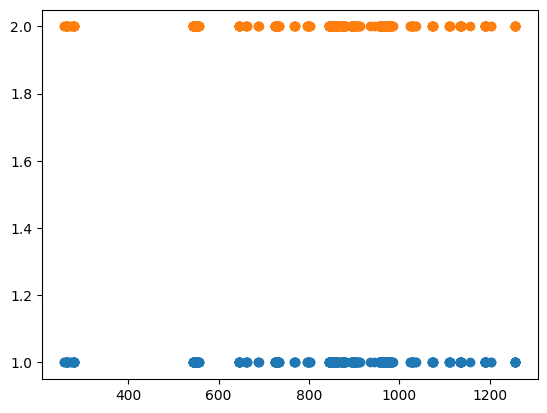

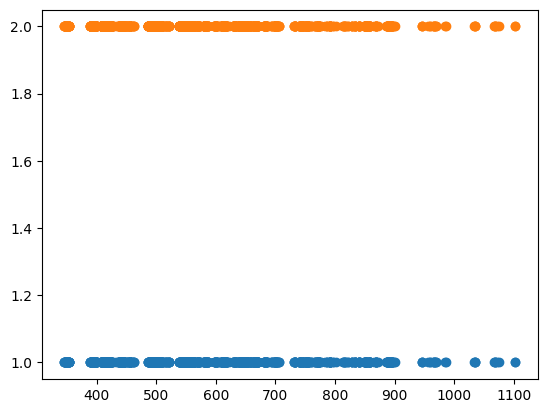

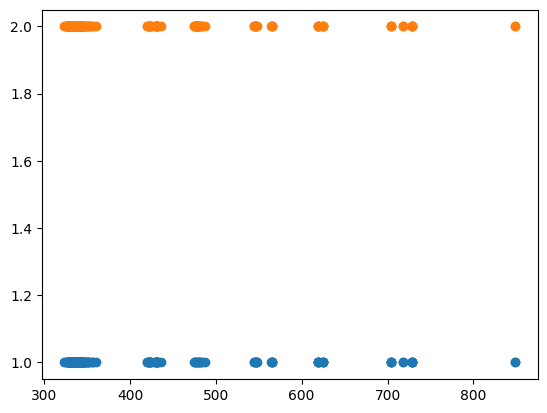

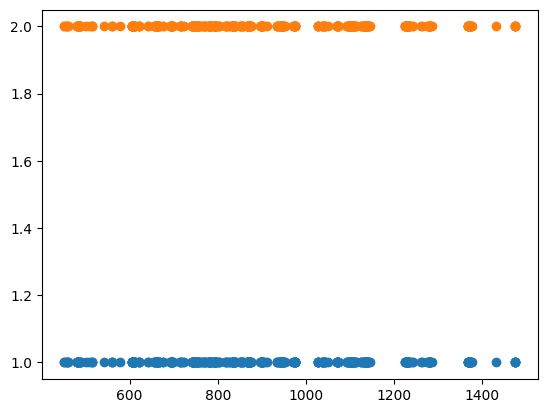

In [22]:
rids=df.record_id.unique()
for rid in rids:
    times=df[df.record_id==rid].time
    level=np.ones(times.shape[0])
    plt.scatter(times,level)
    times=hits[hits.record_id==rid].time
    level=np.ones(times.shape[0])*2
    plt.scatter(times,level)
    plt.show()